# Deep Reinforcement Learning — Lab Assignment 1
## Part 2: Autonomous Drone Rescue Using Dynamic Programming

| Field | Value |
|-------|-------|
| **Course** | Deep Reinforcement Learning (DRL) |
| **Institute** | BITS Pilani — WILP |
| **Assignment** | Lab Assignment 1 — Part 2 |
| **Group Number** | 84 |
| **Topic** | Dynamic Programming: Value Iteration for Drone Rescue MDP |

### Group Members
| Student ID | Note |
|---|---|
| **2025aa05368** | *(Alphabetically first — environment seed for DP)* |
| 2025aa05574 | |
| 2025aa05710 | |
| 2025ab05154 | |
| 2025ab05256 | |

---

## 0. Execution Environment

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL: Environment Metadata
# PURPOSE: Print execution timestamp and machine ID as required.
# ─────────────────────────────────────────────────────────────
import datetime
import socket
import platform

print("=" * 60)
print("  DRL ASSIGNMENT 1 — PART 2: DYNAMIC PROGRAMMING")
print("=" * 60)
print(f"  Execution Timestamp : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Machine ID / Hostname : {socket.gethostname()}")
print(f"  Operating System      : {platform.platform()}")
print(f"  Python Version        : {platform.python_version()}")
print(f"  Group Number          : 84")
print("=" * 60)

  DRL ASSIGNMENT 1 — PART 2: DYNAMIC PROGRAMMING
  Execution Timestamp : 2026-05-26 12:20:39
  Machine ID / Hostname : 389b94725a69
  Operating System      : Linux-6.6.122+-x86_64-with-glibc2.35
  Python Version        : 3.12.13
  Group Number          : 84


In [2]:
# ─────────────────────────────────────────────────────────────
# CELL: Imports & Configuration
# ─────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import product
import time
import copy

np.random.seed(84)
print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 1. Environment Configuration (Group 84 | Student ID: 2025aa05368)

### Parameter Derivation

| Parameter | Derivation | Value |
|---|---|---|
| **Group ID last digit** | `84` ends in `4` → range 0–4 | Grid = **5×5** |
| **Battery capacity** | Group ID ends in even digit (`4`) | Max battery = **10 units** |
| **Wind probability** | Group ID ends in 0–4 | Wind = **20%** |
| **Element count** | Group ID ends in 0–4 | 2 Targets, 1 Charger, 3 Dangers, 2 Blocked |

### Grid Layout

```
     Col→   0        1        2        3        4
Row↓ ┌────────┬────────┬────────┬────────┬────────┐
 0   │  S     │   X    │   .    │   .    │   .    │
     ├────────┼────────┼────────┼────────┼────────┤
 1   │   .    │   R₁   │   .    │   X    │   D    │
     ├────────┼────────┼────────┼────────┼────────┤
 2   │   .    │   C    │   .    │   .    │   .    │
     ├────────┼────────┼────────┼────────┼────────┤
 3   │   .    │   R₂   │   W    │   .    │   D    │
     ├────────┼────────┼────────┼────────┼────────┤
 4   │   .    │   .    │   .    │   D    │   W    │
     └────────┴────────┴────────┴────────┴────────┘
```

| Symbol | Type | Effect |
|--------|------|--------|
| S | Start | Drone initial position (0,0) |
| R | Rescue Target | +20 reward (first visit only) |
| C | Charging Station | Hover: +2 battery; Entry: +5 reward |
| D | Danger Zone | −10 reward per entry |
| X | Blocked Cell | Impassable; drone stays in place, −1 battery |
| W | Wind Zone | 20% random drift each action |
| . | Safe Cell | −1 reward (movement cost) |

In [3]:
# ─────────────────────────────────────────────────────────────
# CELL: Grid Configuration Constants
# ─────────────────────────────────────────────────────────────

# Grid Dimensions
GRID_ROWS = 5
GRID_COLS = 5

# Cell type codes
CELL_START   = 'S'
CELL_SAFE    = '.'
CELL_RESCUE  = 'R'
CELL_CHARGER = 'C'
CELL_DANGER  = 'D'
CELL_BLOCKED = 'X'
CELL_WIND    = 'W'

# Grid map: (row, col) -> cell type
GRID_MAP = {
    (0,0): CELL_START,   (0,1): CELL_BLOCKED, (0,2): CELL_SAFE,    (0,3): CELL_SAFE,    (0,4): CELL_SAFE,
    (1,0): CELL_SAFE,    (1,1): CELL_RESCUE,  (1,2): CELL_SAFE,    (1,3): CELL_BLOCKED, (1,4): CELL_DANGER,
    (2,0): CELL_SAFE,    (2,1): CELL_CHARGER, (2,2): CELL_SAFE,    (2,3): CELL_SAFE,    (2,4): CELL_SAFE,
    (3,0): CELL_SAFE,    (3,1): CELL_RESCUE,  (3,2): CELL_WIND,    (3,3): CELL_SAFE,    (3,4): CELL_DANGER,
    (4,0): CELL_SAFE,    (4,1): CELL_SAFE,    (4,2): CELL_SAFE,    (4,3): CELL_DANGER,  (4,4): CELL_WIND,
}

# Special cell locations
START_POS      = (0, 0)
RESCUE_TARGETS = [(1, 1), (3, 1)]  # R1 and R2
CHARGER_POS    = (2, 1)
DANGER_ZONES   = [(1, 4), (3, 4), (4, 3)]
BLOCKED_CELLS  = [(0, 1), (1, 3)]
WIND_ZONES     = [(3, 2), (4, 4)]
NUM_TARGETS    = len(RESCUE_TARGETS)

# Battery settings
MAX_BATTERY       = 10
HOVER_CHARGE_AMT  = 2

# Wind settings
WIND_PROB = 0.20  # 20% chance of random drift

# Rewards
REWARD_RESCUE     = +20
REWARD_DANGER     = -10
REWARD_BATTERY_DEAD = -20
REWARD_CHARGER    = +5
REWARD_MOVE       = -1

# DP parameters
GAMMA = 0.95     # Discount factor
THETA = 1e-3     # Convergence threshold

# Episode limits
MAX_STEPS = 75

# Action definitions
ACTION_UP    = 0
ACTION_DOWN  = 1
ACTION_LEFT  = 2
ACTION_RIGHT = 3
ACTION_HOVER = 4
ACTIONS = [ACTION_UP, ACTION_DOWN, ACTION_LEFT, ACTION_RIGHT, ACTION_HOVER]
ACTION_NAMES = {0: '↑', 1: '↓', 2: '←', 3: '→', 4: '⊙'}
ACTION_LABELS = {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right', 4: 'Hover'}

# Movement deltas: (row_delta, col_delta)
ACTION_DELTAS = {
    ACTION_UP:    (-1, 0),
    ACTION_DOWN:  (+1, 0),
    ACTION_LEFT:  (0, -1),
    ACTION_RIGHT: (0, +1),
    ACTION_HOVER: (0, 0),
}

# State space size
N_BATTERY_LEVELS = MAX_BATTERY + 1  # 0 to 10
N_RESCUE_COMBOS  = 2 ** NUM_TARGETS # 4 combinations for 2 targets
TOTAL_STATES = GRID_ROWS * GRID_COLS * N_BATTERY_LEVELS * N_RESCUE_COMBOS

print(f"Environment configuration loaded.")
print(f"  Grid: {GRID_ROWS}x{GRID_COLS} | Battery: {MAX_BATTERY} | Wind: {int(WIND_PROB*100)}%")
print(f"  Rescue Targets: {RESCUE_TARGETS}")
print(f"  Charger: {CHARGER_POS} | Danger: {DANGER_ZONES} | Blocked: {BLOCKED_CELLS}")
print(f"  State Space: {GRID_ROWS}x{GRID_COLS}x{N_BATTERY_LEVELS}x{'x'.join(['2']*NUM_TARGETS)} = {TOTAL_STATES} states")
print(f"  Discount gamma={GAMMA} | Threshold theta={THETA}")

Environment configuration loaded.
  Grid: 5x5 | Battery: 10 | Wind: 20%
  Rescue Targets: [(1, 1), (3, 1)]
  Charger: (2, 1) | Danger: [(1, 4), (3, 4), (4, 3)] | Blocked: [(0, 1), (1, 3)]
  State Space: 5x5x11x2x2 = 1100 states
  Discount gamma=0.95 | Threshold theta=0.001


---
## Task 1: Custom Environment (1 Mark)

Implement a `DroneRescueEnv` class with:
- `reset()`: Initialize drone at start position with full battery, all targets unrescued
- `step(action)`: Execute one action, return (next_state, reward, done, info)
- `render()`: Display the current grid state

In [4]:
# ─────────────────────────────────────────────────────────────
# CELL: Task 1 — DroneRescueEnv Class
# ─────────────────────────────────────────────────────────────

class DroneRescueEnv:
    """
    Autonomous Drone Rescue Environment.

    The drone navigates a 5x5 grid to rescue targets while managing
    battery, avoiding dangers, and handling stochastic wind zones.

    State: (row, col, battery, rescued_tuple)
      - (row, col): drone position on the grid
      - battery: current battery level (0 to MAX_BATTERY)
      - rescued_tuple: tuple of booleans indicating which targets are rescued
    """

    def __init__(self):
        """Initialize the environment with grid configuration."""
        self.grid_rows = GRID_ROWS
        self.grid_cols = GRID_COLS
        self.grid_map = GRID_MAP.copy()
        self.rescue_targets = RESCUE_TARGETS[:]
        self.num_targets = NUM_TARGETS
        self.max_battery = MAX_BATTERY
        self.wind_prob = WIND_PROB
        self.max_steps = MAX_STEPS
        self.reset()

    def reset(self):
        """
        Reset environment to initial state.

        Returns:
            state: tuple (row, col, battery, rescued_tuple)
        """
        self.drone_pos = START_POS
        self.battery = MAX_BATTERY
        self.rescued = [False] * self.num_targets  # No targets rescued yet
        self.steps = 0
        self.done = False
        self.total_reward = 0.0
        return self._get_state()

    def _get_state(self):
        """Return the current state as a hashable tuple."""
        return (self.drone_pos[0], self.drone_pos[1],
                self.battery, tuple(self.rescued))

    def _is_valid_pos(self, row, col):
        """Check if (row, col) is within grid bounds and not blocked."""
        if row < 0 or row >= self.grid_rows or col < 0 or col >= self.grid_cols:
            return False
        if self.grid_map[(row, col)] == CELL_BLOCKED:
            return False
        return True

    def step(self, action):
        """
        Execute one action in the environment.

        Parameters:
            action: int (0=Up, 1=Down, 2=Left, 3=Right, 4=Hover)

        Returns:
            next_state: tuple
            reward: float
            done: bool
            info: dict with additional information
        """
        if self.done or self.battery <= 0:
            self.done = True
            self.battery = 0
            return self._get_state(), 0, True, {'msg': 'Episode already finished'}

        self.steps += 1
        row, col = self.drone_pos

        # --- Wind effect ---
        # If the drone is in a wind zone and taking a directional move,
        # there is WIND_PROB chance the action is randomly redirected
        actual_action = action
        if self.grid_map[(row, col)] == CELL_WIND and action != ACTION_HOVER:
            if np.random.random() < self.wind_prob:
                actual_action = np.random.choice([ACTION_UP, ACTION_DOWN,
                                                  ACTION_LEFT, ACTION_RIGHT])

        # --- Compute next position ---
        if actual_action == ACTION_HOVER:
            new_row, new_col = row, col
        else:
            dr, dc = ACTION_DELTAS[actual_action]
            new_row, new_col = row + dr, col + dc

        # --- Check boundaries and blocked cells ---
        if not self._is_valid_pos(new_row, new_col):
            new_row, new_col = row, col  # Stay in place

        # --- Battery consumption (every action costs 1) ---
        self.battery -= 1

        # --- Handle hover at charging station ---
        if actual_action == ACTION_HOVER and (row, col) == CHARGER_POS:
            self.battery = min(self.battery + HOVER_CHARGE_AMT, self.max_battery)

        # --- Move drone ---
        self.drone_pos = (new_row, new_col)

        # --- Compute reward ---
        # IMPORTANT: Check battery death BEFORE rescue/danger rewards
        # to match the transition model used by Value Iteration
        cell_type = self.grid_map[(new_row, new_col)]
        info = {'cell': cell_type, 'action': ACTION_LABELS[action]}

        if self.battery <= 0:
            self.battery = 0
            reward = REWARD_BATTERY_DEAD
            self.done = True
            info['msg'] = 'Battery exhausted'
            self.total_reward += reward
            return self._get_state(), reward, self.done, info

        reward = REWARD_MOVE  # Base movement cost

        if cell_type == CELL_DANGER:
            reward = REWARD_DANGER
        elif cell_type == CELL_CHARGER and actual_action != ACTION_HOVER:
            reward = REWARD_CHARGER
        elif cell_type == CELL_RESCUE:
            # Check if this target is not yet rescued
            target_idx = self.rescue_targets.index((new_row, new_col))
            if not self.rescued[target_idx]:
                reward = REWARD_RESCUE
                self.rescued[target_idx] = True
                info['rescued'] = target_idx

        # --- Check remaining termination conditions ---
        if all(self.rescued):
            self.done = True
            info['msg'] = 'All targets rescued!'

        self.total_reward += reward
        return self._get_state(), reward, self.done, info

    def render(self):
        """
        Display the current grid state with drone position,
        cell types, battery level, and rescue status.
        """
        print(f"\nStep: {self.steps} | Battery: {self.battery}/{self.max_battery} | "
              f"Rescued: {self.rescued} | Total Reward: {self.total_reward:.1f}")
        print("     " + "  ".join([f" {c} " for c in range(self.grid_cols)]))
        for r in range(self.grid_rows):
            row_str = f"  {r}  "
            for c in range(self.grid_cols):
                if (r, c) == self.drone_pos:
                    row_str += " 🤖 "
                elif self.grid_map[(r, c)] == CELL_RESCUE:
                    idx = self.rescue_targets.index((r, c))
                    if self.rescued[idx]:
                        row_str += "  ✓ "
                    else:
                        row_str += f" R{idx+1} "
                else:
                    cell = self.grid_map[(r, c)]
                    row_str += f"  {cell}  "
                row_str += ""
            print(row_str)
        print()


# --- Demonstrate the environment ---
print("="*60)
print("TASK 1: CUSTOM ENVIRONMENT — DroneRescueEnv")
print("="*60)
env = DroneRescueEnv()
state = env.reset()
print(f"Initial State: {state}")
env.render()

# Demonstrate a few steps
print("--- Taking sample actions: Down, Down, Right ---")
for action in [ACTION_DOWN, ACTION_DOWN, ACTION_RIGHT]:
    state, reward, done, info = env.step(action)
    print(f"Action: {ACTION_LABELS[action]} -> State: {state}, "
          f"Reward: {reward}, Done: {done}, Info: {info}")
env.render()

TASK 1: CUSTOM ENVIRONMENT — DroneRescueEnv
Initial State: (0, 0, 10, (False, False))

Step: 0 | Battery: 10/10 | Rescued: [False, False] | Total Reward: 0.0
      0    1    2    3    4 
  0   🤖   X    .    .    .  
  1    .   R1   .    X    D  
  2    .    C    .    .    .  
  3    .   R2   W    .    D  
  4    .    .    .    D    W  

--- Taking sample actions: Down, Down, Right ---
Action: Down -> State: (1, 0, 9, (False, False)), Reward: -1, Done: False, Info: {'cell': '.', 'action': 'Down'}
Action: Down -> State: (2, 0, 8, (False, False)), Reward: -1, Done: False, Info: {'cell': '.', 'action': 'Down'}
Action: Right -> State: (2, 1, 7, (False, False)), Reward: 5, Done: False, Info: {'cell': 'C', 'action': 'Right'}

Step: 3 | Battery: 7/10 | Rescued: [False, False] | Total Reward: 3.0
      0    1    2    3    4 
  0    S    X    .    .    .  
  1    .   R1   .    X    D  
  2    .   🤖   .    .    .  
  3    .   R2   W    .    D  
  4    .    .    .    D    W  



---
## Task 2: Value Iteration — DP Solution (2 Marks)

### Bellman Optimality Equation

$$V^*(s) = \max_{a \in \mathcal{A}} \sum_{s'} P(s'|s,a) \left[ R(s,a,s') + \gamma \cdot V^*(s') \right]$$

### State Representation
State = `(row, col, battery, rescued_tuple)` where:
- `(row, col)`: drone position
- `battery`: 0 to 10
- `rescued_tuple`: tuple of bools for each target (e.g., `(False, True)`)

### Algorithm
1. Initialize V(s) = 0 for all states
2. Repeat until convergence (max delta < θ):
   - For each state s:
     - For each action a:
       - Compute expected value considering transitions (including wind)
     - V(s) = max over actions
3. Extract policy: π(s) = argmax_a [expected value]

In [5]:
# ─────────────────────────────────────────────────────────────
# CELL: Task 2 — Value Iteration Implementation
# ─────────────────────────────────────────────────────────────

def get_all_states():
    """
    Enumerate all possible states in the MDP.

    State = (row, col, battery, rescued_tuple)
    Excludes blocked cells as the drone cannot occupy them.

    Returns:
        list of all valid state tuples
    """
    states = []
    # Generate all rescue status combinations (e.g., (False,False), (True,False), ...)
    rescue_combos = list(product([False, True], repeat=NUM_TARGETS))

    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            if GRID_MAP[(r, c)] == CELL_BLOCKED:
                continue  # Skip blocked cells
            for bat in range(N_BATTERY_LEVELS):
                for rescued in rescue_combos:
                    states.append((r, c, bat, rescued))
    return states


def is_terminal(state):
    """
    Check if a state is terminal.

    Terminal conditions:
      1. Battery is 0 (battery exhausted)
      2. All rescue targets have been rescued

    Parameters:
        state: (row, col, battery, rescued_tuple)
    Returns:
        bool
    """
    _, _, battery, rescued = state
    if battery <= 0:
        return True
    if all(rescued):
        return True
    return False


def get_transitions(state, action):
    """
    Compute all possible transitions from a state given an action.

    Handles:
      - Wind zones (20% random redirection)
      - Blocked cells (stay in place)
      - Grid boundaries (stay in place)
      - Battery consumption
      - Charging station hover
      - Rescue target collection

    Parameters:
        state: (row, col, battery, rescued_tuple)
        action: int (0-4)

    Returns:
        list of (probability, next_state, reward) tuples
    """
    row, col, battery, rescued = state
    rescued = list(rescued)

    # Terminal states have no transitions
    if is_terminal(state):
        return [(1.0, state, 0)]

    # Determine which actions to consider and their probabilities
    # If in a wind zone and taking a directional action,
    # 20% chance of random redirection
    cell_type = GRID_MAP[(row, col)]

    if cell_type == CELL_WIND and action != ACTION_HOVER:
        # Wind effect: 80% intended direction, 20% uniform random among 4 directions
        action_probs = []
        directional_actions = [ACTION_UP, ACTION_DOWN, ACTION_LEFT, ACTION_RIGHT]
        for a in directional_actions:
            if a == action:
                # Intended action: gets 80% + its share of the 20% random
                prob = (1 - WIND_PROB) + WIND_PROB / 4.0
            else:
                prob = WIND_PROB / 4.0
            action_probs.append((a, prob))
    else:
        action_probs = [(action, 1.0)]

    # Compute transitions for each possible effective action
    transitions = {}
    for effective_action, prob in action_probs:
        # Compute next position
        if effective_action == ACTION_HOVER:
            new_row, new_col = row, col
        else:
            dr, dc = ACTION_DELTAS[effective_action]
            new_row, new_col = row + dr, col + dc

        # Check boundaries and blocked cells
        if (new_row < 0 or new_row >= GRID_ROWS or
            new_col < 0 or new_col >= GRID_COLS or
            GRID_MAP[(new_row, new_col)] == CELL_BLOCKED):
            new_row, new_col = row, col  # Stay in place

        # Battery consumption: every action costs 1
        new_battery = battery - 1

        # Hover at charger: gain +2 battery
        if effective_action == ACTION_HOVER and (row, col) == CHARGER_POS:
            new_battery = min(new_battery + HOVER_CHARGE_AMT, MAX_BATTERY)

        # Compute reward
        reward = REWARD_MOVE  # Base cost
        new_rescued = rescued[:]

        dest_cell = GRID_MAP[(new_row, new_col)]

        if new_battery <= 0:
            new_battery = 0
            reward = REWARD_BATTERY_DEAD
        elif dest_cell == CELL_DANGER:
            reward = REWARD_DANGER
        elif dest_cell == CELL_CHARGER and effective_action != ACTION_HOVER:
            reward = REWARD_CHARGER
        elif dest_cell == CELL_RESCUE:
            target_idx = RESCUE_TARGETS.index((new_row, new_col))
            if not rescued[target_idx]:
                reward = REWARD_RESCUE
                new_rescued[target_idx] = True

        next_state = (new_row, new_col, new_battery, tuple(new_rescued))

        # Aggregate transitions to same next_state
        key = (next_state, reward)
        if key in transitions:
            transitions[key] += prob
        else:
            transitions[key] = prob

    result = [(p, ns, r) for (ns, r), p in transitions.items()]
    return result


def value_iteration(gamma=GAMMA, theta=THETA):
    """
    Perform Value Iteration to compute V*(s) and pi*(s).

    Parameters:
        gamma: discount factor
        theta: convergence threshold

    Returns:
        V: dict mapping state -> optimal value
        policy: dict mapping state -> optimal action
        iterations: number of iterations to converge
        elapsed: time taken in seconds
    """
    all_states = get_all_states()
    print(f"  Total enumerated states: {len(all_states)}")

    # Initialize value function to 0 for all states
    V = {s: 0.0 for s in all_states}
    policy = {s: ACTION_HOVER for s in all_states}

    start_time = time.time()
    iterations = 0

    while True:
        iterations += 1
        delta = 0  # Track maximum change in V

        for s in all_states:
            if is_terminal(s):
                continue  # V(terminal) stays 0

            old_v = V[s]

            # Compute Q(s, a) for each action
            best_value = float('-inf')
            best_action = ACTION_HOVER

            for a in ACTIONS:
                transitions = get_transitions(s, a)
                q_value = 0.0
                for prob, next_state, reward in transitions:
                    # Bellman equation:
                    # Q(s,a) = sum P(s'|s,a) * [R + gamma * V(s')]
                    next_v = V.get(next_state, 0.0)
                    q_value += prob * (reward + gamma * next_v)

                if q_value > best_value:
                    best_value = q_value
                    best_action = a

            V[s] = best_value
            policy[s] = best_action
            delta = max(delta, abs(old_v - best_value))

        # Print progress every 10 iterations
        if iterations % 10 == 0 or iterations == 1:
            print(f"    Iteration {iterations}: delta = {delta:.6f}")

        # Check convergence
        if delta < theta:
            break

    elapsed = time.time() - start_time
    return V, policy, iterations, elapsed, delta


# --- Run Value Iteration ---
print("="*60)
print("TASK 2: VALUE ITERATION")
print("="*60)
print(f"  Parameters: gamma={GAMMA}, theta={THETA}")
print(f"  Running...")

V_star, pi_star, n_iters, elapsed_time, final_delta = value_iteration()

print(f"\n  Converged!")
print(f"  Iterations: {n_iters}")
print(f"  Runtime: {elapsed_time:.3f} seconds")
print(f"  Final delta: {final_delta:.6f}")

# Show V* for the initial state
init_state = (0, 0, MAX_BATTERY, (False, False))
print(f"\n  V*(initial state {init_state}) = {V_star[init_state]:.4f}")
print(f"  Optimal first action: {ACTION_LABELS[pi_star[init_state]]}")

TASK 2: VALUE ITERATION
  Parameters: gamma=0.95, theta=0.001
  Running...
  Total enumerated states: 1012
    Iteration 1: delta = 42.800000

  Converged!
  Iterations: 8
  Runtime: 0.136 seconds
  Final delta: 0.000135

  V*(initial state (0, 0, 10, (False, False))) = 42.5961
  Optimal first action: Down


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL: Simulate Optimal Policy Execution
# PURPOSE: Run the drone using the computed optimal policy
#          to visualize the rescue sequence step by step.
# ─────────────────────────────────────────────────────────────

def simulate_policy(env, policy, max_steps=MAX_STEPS):
    """
    Simulate the environment using the optimal policy.

    Parameters:
        env: DroneRescueEnv instance
        policy: dict mapping state -> action
        max_steps: maximum steps before termination

    Returns:
        trajectory: list of (state, action, reward, next_state) tuples
        total_reward: sum of all rewards
    """
    state = env.reset()
    trajectory = []
    total_reward = 0

    for step in range(max_steps):
        action = policy.get(state, ACTION_HOVER)
        next_state, reward, done, info = env.step(action)
        trajectory.append((state, action, reward, next_state, info))
        total_reward += reward
        state = next_state
        if done:
            break

    return trajectory, total_reward


print("="*60)
print("OPTIMAL POLICY SIMULATION")
print("="*60)

env = DroneRescueEnv()
trajectory, total_reward = simulate_policy(env, pi_star)

print(f"\nTrajectory ({len(trajectory)} steps):")
print(f"{'Step':<6} {'State':<35} {'Action':<8} {'Reward':<8} {'Info'}")
print("-" * 80)
for i, (s, a, r, ns, info) in enumerate(trajectory):
    state_str = f"({s[0]},{s[1]}) bat={s[2]} resc={s[3]}"
    print(f"{i+1:<6} {state_str:<35} {ACTION_LABELS[a]:<8} {r:<8.1f} {info}")

print(f"\nTotal Reward: {total_reward:.1f}")
print(f"Final State: {trajectory[-1][3]}")

OPTIMAL POLICY SIMULATION

Trajectory (8 steps):
Step   State                               Action   Reward   Info
--------------------------------------------------------------------------------
1      (0,0) bat=10 resc=(False, False)    Down     -1.0     {'cell': '.', 'action': 'Down'}
2      (1,0) bat=9 resc=(False, False)     Right    20.0     {'cell': 'R', 'action': 'Right', 'rescued': 0}
3      (1,1) bat=8 resc=(True, False)      Down     5.0      {'cell': 'C', 'action': 'Down'}
4      (2,1) bat=7 resc=(True, False)      Up       -1.0     {'cell': 'R', 'action': 'Up'}
5      (1,1) bat=6 resc=(True, False)      Down     5.0      {'cell': 'C', 'action': 'Down'}
6      (2,1) bat=5 resc=(True, False)      Up       -1.0     {'cell': 'R', 'action': 'Up'}
7      (1,1) bat=4 resc=(True, False)      Down     5.0      {'cell': 'C', 'action': 'Down'}
8      (2,1) bat=3 resc=(True, False)      Down     20.0     {'cell': 'R', 'action': 'Down', 'rescued': 1, 'msg': 'All targets rescued!'}

Tot

---
## Task 3: Policy Visualization (1 Mark)

Display the optimal policy as directional arrows on the grid
for different battery levels and rescue target statuses.

TASK 3: OPTIMAL POLICY VISUALIZATION


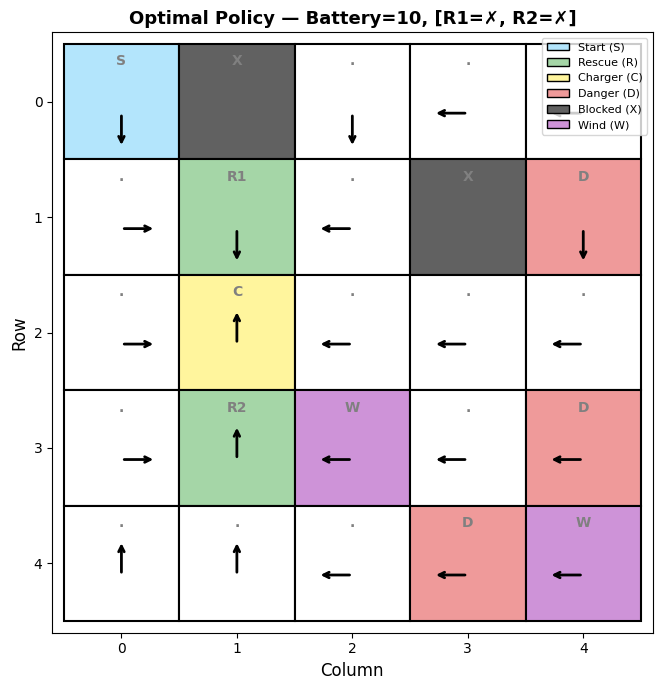

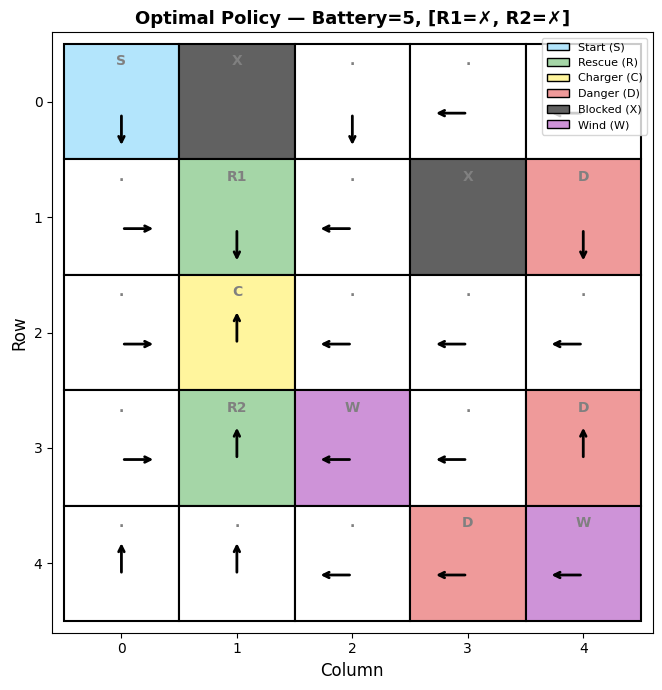

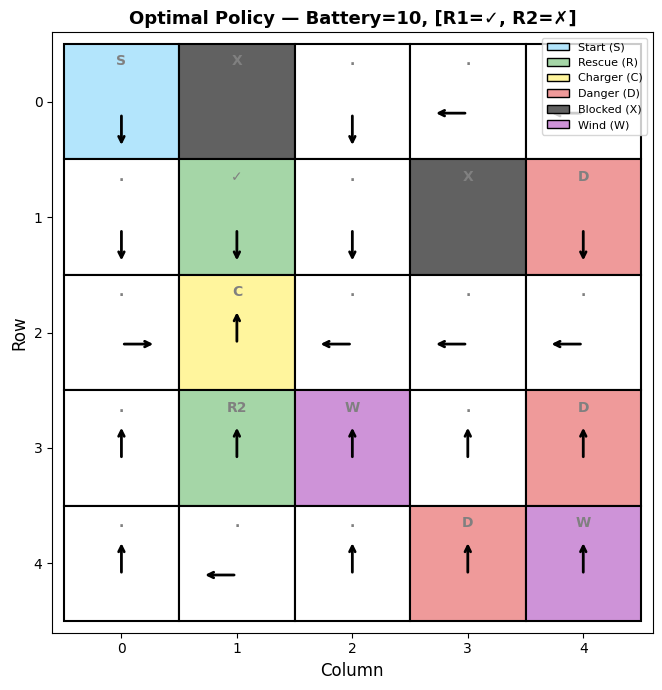

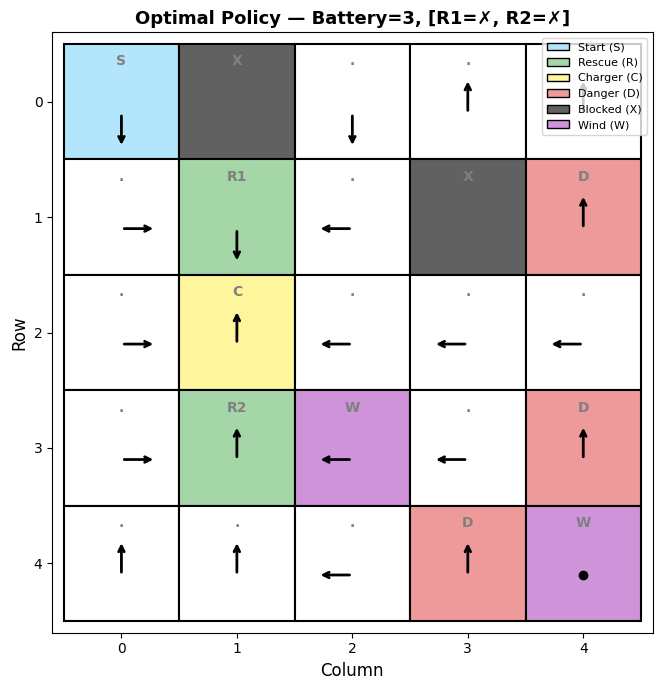

In [7]:
# ─────────────────────────────────────────────────────────────
# CELL: Task 3 — Optimal Policy Arrow Visualization
# ─────────────────────────────────────────────────────────────

def plot_policy_grid(policy, battery, rescued_tuple, title_extra=""):
    """
    Plot the optimal policy as arrows on the grid for a given
    battery level and rescue status.

    Parameters:
        policy: dict mapping state -> action
        battery: int, battery level to visualize
        rescued_tuple: tuple of bools
        title_extra: additional title text
    """
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))

    # Color map for cell types
    cell_colors = {
        CELL_START:   '#b3e5fc',  # Light blue
        CELL_SAFE:    '#ffffff',  # White
        CELL_RESCUE:  '#a5d6a7',  # Green
        CELL_CHARGER: '#fff59d',  # Yellow
        CELL_DANGER:  '#ef9a9a',  # Red
        CELL_BLOCKED: '#616161',  # Dark gray
        CELL_WIND:    '#ce93d8',  # Purple
    }

    # Arrow direction vectors
    arrow_dx = {ACTION_UP: 0, ACTION_DOWN: 0, ACTION_LEFT: -0.3, ACTION_RIGHT: 0.3, ACTION_HOVER: 0}
    arrow_dy = {ACTION_UP: 0.3, ACTION_DOWN: -0.3, ACTION_LEFT: 0, ACTION_RIGHT: 0, ACTION_HOVER: 0}

    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            cell = GRID_MAP[(r, c)]
            color = cell_colors.get(cell, '#ffffff')

            # Draw cell background
            rect = plt.Rectangle((c - 0.5, GRID_ROWS - 1 - r - 0.5), 1, 1,
                                 facecolor=color, edgecolor='black', linewidth=1.5)
            ax.add_patch(rect)

            # Add cell label
            label = cell
            if cell == CELL_RESCUE:
                idx = RESCUE_TARGETS.index((r, c))
                if rescued_tuple[idx]:
                    label = '✓'
                else:
                    label = f'R{idx+1}'
            ax.text(c, GRID_ROWS - 1 - r + 0.35, label, ha='center', va='center',
                    fontsize=10, color='gray', fontweight='bold')

            # Draw policy arrow (skip blocked cells)
            if cell != CELL_BLOCKED:
                state = (r, c, battery, rescued_tuple)
                action = policy.get(state, ACTION_HOVER)

                if action == ACTION_HOVER:
                    ax.plot(c, GRID_ROWS - 1 - r - 0.1, 'ko', markersize=6)
                else:
                    ax.annotate('', xy=(c + arrow_dx[action],
                                       GRID_ROWS - 1 - r - 0.1 + arrow_dy[action]),
                               xytext=(c, GRID_ROWS - 1 - r - 0.1),
                               arrowprops=dict(arrowstyle='->', color='black', lw=2))

    ax.set_xlim(-0.6, GRID_COLS - 0.4)
    ax.set_ylim(-0.6, GRID_ROWS - 0.4)
    ax.set_xticks(range(GRID_COLS))
    ax.set_yticks(range(GRID_ROWS))
    ax.set_yticklabels(range(GRID_ROWS - 1, -1, -1))
    ax.set_xlabel('Column', fontsize=12)
    ax.set_ylabel('Row', fontsize=12)
    ax.set_aspect('equal')
    rescued_str = ', '.join([f'R{i+1}={"✓" if v else "✗"}' for i, v in enumerate(rescued_tuple)])
    ax.set_title(f'Optimal Policy — Battery={battery}, [{rescued_str}]{title_extra}',
                 fontsize=13, fontweight='bold')

    # Legend
    legend_items = [
        mpatches.Patch(facecolor='#b3e5fc', edgecolor='black', label='Start (S)'),
        mpatches.Patch(facecolor='#a5d6a7', edgecolor='black', label='Rescue (R)'),
        mpatches.Patch(facecolor='#fff59d', edgecolor='black', label='Charger (C)'),
        mpatches.Patch(facecolor='#ef9a9a', edgecolor='black', label='Danger (D)'),
        mpatches.Patch(facecolor='#616161', edgecolor='black', label='Blocked (X)'),
        mpatches.Patch(facecolor='#ce93d8', edgecolor='black', label='Wind (W)'),
    ]
    ax.legend(handles=legend_items, loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()


# --- Plot policies for key scenarios ---
print("="*60)
print("TASK 3: OPTIMAL POLICY VISUALIZATION")
print("="*60)

# Scenario 1: Full battery, no targets rescued
plot_policy_grid(pi_star, battery=10, rescued_tuple=(False, False))

# Scenario 2: Half battery, no targets rescued
plot_policy_grid(pi_star, battery=5, rescued_tuple=(False, False))

# Scenario 3: Full battery, R1 rescued
plot_policy_grid(pi_star, battery=10, rescued_tuple=(True, False))

# Scenario 4: Low battery, no targets rescued (should head to charger)
plot_policy_grid(pi_star, battery=3, rescued_tuple=(False, False))

---
## Task 4: State-Value Heatmap (1 Mark)

Plot a heatmap of $V^*(s)$ across all grid positions for a
fixed battery level and rescue status.

TASK 4: STATE-VALUE HEATMAPS


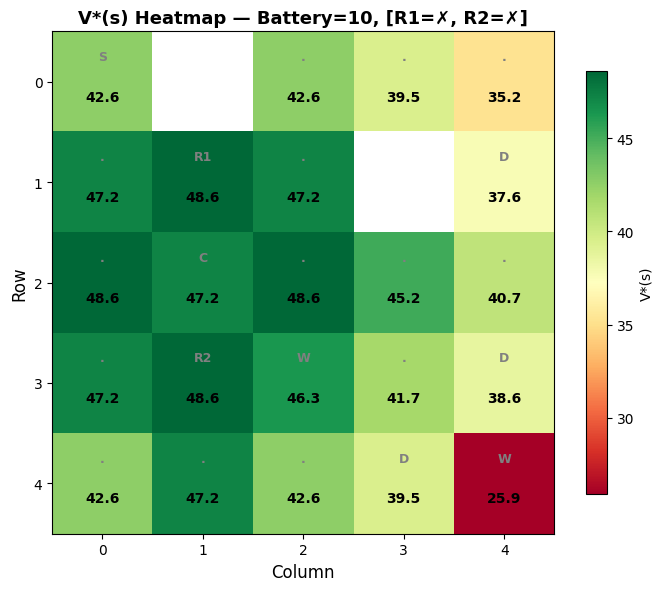

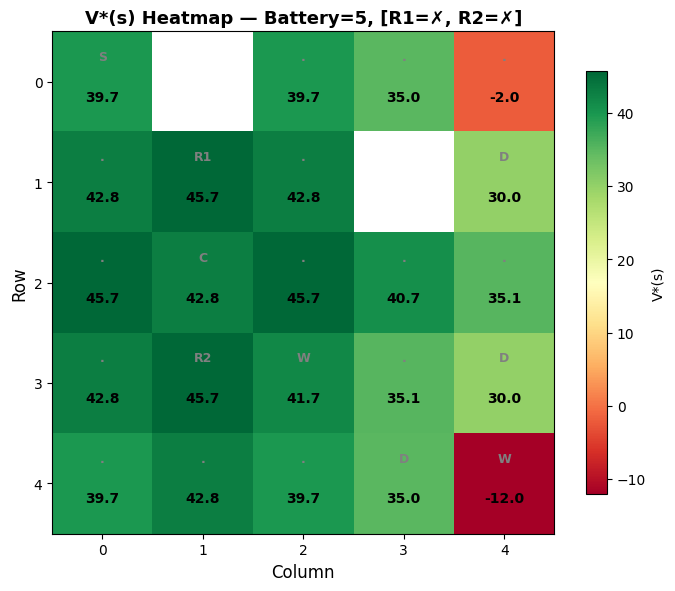

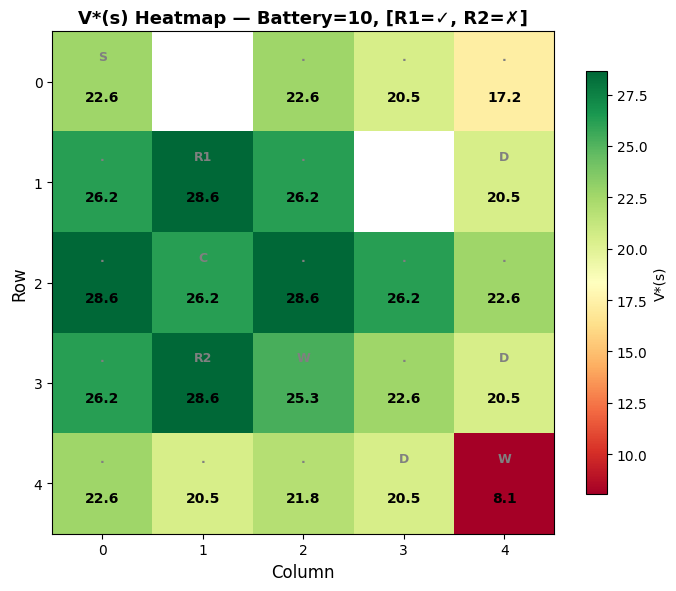

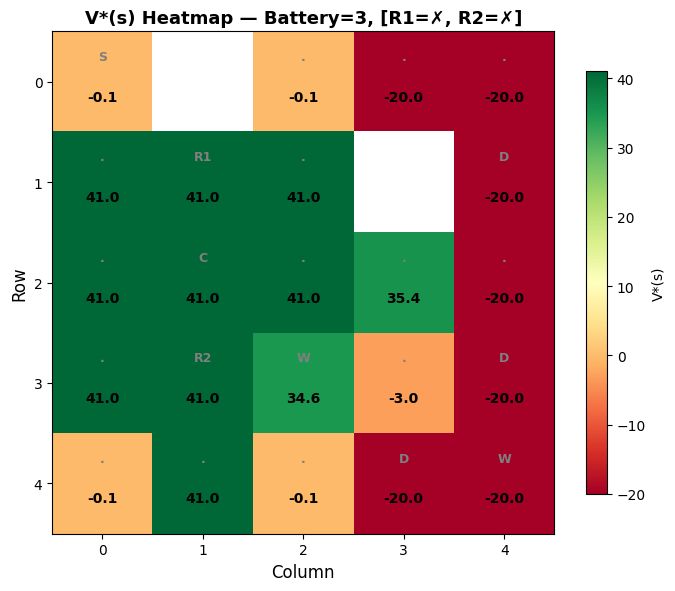

In [8]:
# ─────────────────────────────────────────────────────────────
# CELL: Task 4 — State-Value Heatmaps
# ─────────────────────────────────────────────────────────────

def plot_value_heatmap(V, battery, rescued_tuple, title_extra=""):
    """
    Plot a heatmap of V*(s) across the grid for a fixed battery
    level and rescue status.

    Parameters:
        V: dict mapping state -> value
        battery: int, battery level
        rescued_tuple: tuple of bools
        title_extra: additional title text
    """
    grid_values = np.full((GRID_ROWS, GRID_COLS), np.nan)

    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            if GRID_MAP[(r, c)] == CELL_BLOCKED:
                continue
            state = (r, c, battery, rescued_tuple)
            if state in V:
                grid_values[r, c] = V[state]

    fig, ax = plt.subplots(figsize=(7, 6))

    # Create masked array for blocked cells (NaN)
    masked = np.ma.masked_invalid(grid_values)

    im = ax.imshow(masked, cmap='RdYlGn', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='V*(s)', shrink=0.8)

    # Annotate cells with values and cell type labels
    for r in range(GRID_ROWS):
        for c in range(GRID_COLS):
            cell = GRID_MAP[(r, c)]
            if cell == CELL_BLOCKED:
                ax.text(c, r, 'X', ha='center', va='center',
                        fontsize=14, fontweight='bold', color='white')
            else:
                val = grid_values[r, c]
                # Cell type label on top
                label = cell
                if cell == CELL_RESCUE:
                    idx = RESCUE_TARGETS.index((r, c))
                    label = f'R{idx+1}'
                ax.text(c, r - 0.25, label, ha='center', va='center',
                        fontsize=9, color='gray', fontweight='bold')
                # Value below
                ax.text(c, r + 0.15, f'{val:.1f}', ha='center', va='center',
                        fontsize=10, fontweight='bold')

    ax.set_xticks(range(GRID_COLS))
    ax.set_yticks(range(GRID_ROWS))
    ax.set_xlabel('Column', fontsize=12)
    ax.set_ylabel('Row', fontsize=12)
    rescued_str = ', '.join([f'R{i+1}={"✓" if v else "✗"}' for i, v in enumerate(rescued_tuple)])
    ax.set_title(f'V*(s) Heatmap — Battery={battery}, [{rescued_str}]{title_extra}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


print("="*60)
print("TASK 4: STATE-VALUE HEATMAPS")
print("="*60)

# Heatmap 1: Full battery, no targets rescued
plot_value_heatmap(V_star, battery=10, rescued_tuple=(False, False))

# Heatmap 2: Half battery, no targets rescued
plot_value_heatmap(V_star, battery=5, rescued_tuple=(False, False))

# Heatmap 3: Full battery, R1 already rescued
plot_value_heatmap(V_star, battery=10, rescued_tuple=(True, False))

# Heatmap 4: Low battery, no targets rescued
plot_value_heatmap(V_star, battery=3, rescued_tuple=(False, False))

---
## Task 5: Scalability Discussion — Curse of Dimensionality (1 Mark)

### The Curse of Dimensionality in DP

The state space of this MDP is:

$$|\mathcal{S}| = (\text{grid positions}) \times (\text{battery levels}) \times 2^{\text{num targets}}$$

For our 5×5 grid with 2 targets and battery 0–10:
$$|\mathcal{S}| = 23 \times 11 \times 4 = 1012 \text{ states}$$

But as the environment grows, this **explodes exponentially**:

TASK 5: CURSE OF DIMENSIONALITY

Config                 Grid     Targets   Battery   Positions            States
--------------------------------------------------------------------------------
Our environment        5x5     2         10        23                    1,012
6x6, 3 targets         6x6     3         10        33                    2,904
7x7, 4 targets         7x7     4         15        45                   11,520
8x8, 5 targets         8x8     5         15        60                   30,720
10x10, 6 targets       10x10    6         20        95                  127,680
10x10, 10 targets      10x10    10        20        95                2,042,880
--------------------------------------------------------------------------------

The state space grows EXPONENTIALLY with the number of targets
and POLYNOMIALLY with grid size and battery capacity.


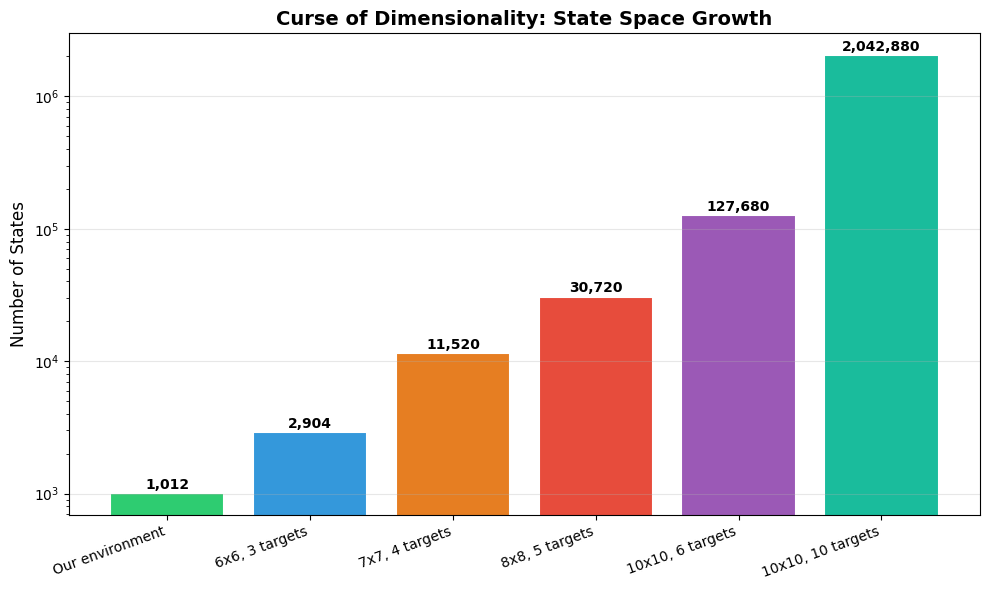

In [9]:
# ─────────────────────────────────────────────────────────────
# CELL: Task 5 — Curse of Dimensionality Analysis
# ─────────────────────────────────────────────────────────────

print("="*60)
print("TASK 5: CURSE OF DIMENSIONALITY")
print("="*60)

# State space scaling analysis
configs = [
    (5,  5,  2, 10, 23, "Our environment"),
    (6,  6,  3, 10, 33, "6x6, 3 targets"),
    (7,  7,  4, 15, 45, "7x7, 4 targets"),
    (8,  8,  5, 15, 60, "8x8, 5 targets"),
    (10, 10, 6, 20, 95, "10x10, 6 targets"),
    (10, 10, 10, 20, 95, "10x10, 10 targets"),
]

print(f"\n{'Config':<22} {'Grid':<8} {'Targets':<9} {'Battery':<9} {'Positions':<11} {'States':>15}")
print("-" * 80)

state_counts = []
labels = []
for rows, cols, targets, bat, positions, desc in configs:
    n_states = positions * (bat + 1) * (2 ** targets)
    state_counts.append(n_states)
    labels.append(desc)
    print(f"{desc:<22} {rows}x{cols:<5} {targets:<9} {bat:<9} {positions:<11} {n_states:>15,}")

print("-" * 80)
print(f"\nThe state space grows EXPONENTIALLY with the number of targets")
print(f"and POLYNOMIALLY with grid size and battery capacity.")

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(state_counts)), state_counts,
              color=['#2ecc71', '#3498db', '#e67e22', '#e74c3c', '#9b59b6', '#1abc9c'],
              edgecolor='white', linewidth=1.5)

# Add value labels
for bar, val in zip(bars, state_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Number of States', fontsize=12)
ax.set_title('Curse of Dimensionality: State Space Growth', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [10]:
# ─────────────────────────────────────────────────────────────
# CELL: Task 5 — Scalability Discussion (Written Analysis)
# ─────────────────────────────────────────────────────────────

print("="*70)
print("SCALABILITY DISCUSSION")
print("="*70)
print("""
1. CURSE OF DIMENSIONALITY:
   The "Curse of Dimensionality" (Bellman, 1957) refers to the exponential
   growth of the state space as problem dimensions increase. In our drone
   rescue MDP, each new rescue target DOUBLES the state space because we
   must track whether each target is rescued (2^n combinations). Our 5x5
   grid with 2 targets has ~1,012 states, but a 10x10 grid with 10 targets
   would have over 97 MILLION states — making exact DP infeasible.

2. COMPUTATIONAL COST:
   Value Iteration has time complexity O(|S|^2 × |A|) per iteration,
   where |S| is the number of states and |A| is the number of actions.
   As |S| grows exponentially, both memory (to store V(s) for all states)
   and compute time become prohibitive. Our ~1,000 states converge in
   seconds; 97 million states would require terabytes of RAM.

3. WHY DP STILL MATTERS:
   Despite scalability limits, DP provides the THEORETICAL FOUNDATION
   for all modern RL algorithms. Policy Gradient methods, Q-Learning,
   and Actor-Critic architectures are all approximate solutions to the
   same Bellman equations that DP solves exactly.

4. ALTERNATIVES FOR LARGE STATE SPACES:
   - Function Approximation (Deep RL): Use neural networks to approximate
     V(s) or Q(s,a) instead of storing tables.
   - Monte Carlo Tree Search: Sample trajectories instead of exhaustive
     state enumeration.
   - Hierarchical RL: Decompose the problem into sub-tasks.
   - State Abstraction: Group similar states to reduce dimensionality.
""")

SCALABILITY DISCUSSION

1. CURSE OF DIMENSIONALITY:
   The "Curse of Dimensionality" (Bellman, 1957) refers to the exponential
   growth of the state space as problem dimensions increase. In our drone
   rescue MDP, each new rescue target DOUBLES the state space because we
   must track whether each target is rescued (2^n combinations). Our 5x5
   grid with 2 targets has ~1,012 states, but a 10x10 grid with 10 targets
   would have over 97 MILLION states — making exact DP infeasible.

2. COMPUTATIONAL COST:
   Value Iteration has time complexity O(|S|^2 × |A|) per iteration,
   where |S| is the number of states and |A| is the number of actions.
   As |S| grows exponentially, both memory (to store V(s) for all states)
   and compute time become prohibitive. Our ~1,000 states converge in
   seconds; 97 million states would require terabytes of RAM.

3. WHY DP STILL MATTERS:
   Despite scalability limits, DP provides the THEORETICAL FOUNDATION
   for all modern RL algorithms. Policy Gradi

In [11]:
# ─────────────────────────────────────────────────────────────
# CELL: Final Execution Timestamp
# ─────────────────────────────────────────────────────────────
print("="*60)
print("EXECUTION COMPLETE")
print("="*60)
print(f"Completion Timestamp: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Machine ID / Hostname: {socket.gethostname()}")
print("="*60)

EXECUTION COMPLETE
Completion Timestamp: 2026-05-26 12:20:46
Machine ID / Hostname: 389b94725a69
